In this notebok i'll be trying to attempt to train 2 different models....
1. First one on the raw features + magic_score(calculated using orignal dataset of the competition)
2. Second one completely on magic_score and magic_features also some digit decomposition

Finally ending it with a weighted ensemble, this approach of training multiple models which catch diverse signals was inspired by a rescent competition top solution

In [86]:
#imports 
import pandas as pd
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import balanced_accuracy_score
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import seaborn as sns
import matplotlib.pyplot as plt

## Importing data:

In [87]:
comp_data_path = '/kaggle/input/competitions/playground-series-s6e4/'
orig_path = '/kaggle/input/datasets/miadul/irrigation-water-requirement-prediction-dataset/irrigation_prediction.csv'

train_df = pd.read_csv(comp_data_path + 'train.csv')
print('Train data: ', train_df.shape)
display(train_df.head())

orig_df = pd.read_csv(orig_path)
print('Orignal data: ', orig_df.shape)
display(orig_df.head())

test_df = pd.read_csv(comp_data_path + 'test.csv')
print('Test data: ', test_df.shape)
display(test_df.head())

Train data:  (630000, 21)


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


Orignal data:  (10000, 20)


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South,Medium


Test data:  (270000, 20)


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,630000,Silt,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,Maize,Sowing,Rabi,Canal,River,13.59,Yes,47.48,West
1,630001,Clay,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,Cotton,Sowing,Rabi,Drip,Reservoir,6.12,Yes,56.43,South
2,630002,Sandy,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.11,Yes,20.00,East
3,630003,Clay,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,Maize,Harvest,Rabi,Canal,Groundwater,2.27,No,102.99,North
4,630004,Loamy,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,Cotton,Sowing,Kharif,Canal,Groundwater,12.39,Yes,13.33,Central


In [88]:
target = 'Irrigation_Need'

X = train_df.drop(columns=['id', target], axis=1)
X_orig = orig_df.drop(target, axis=1)
X_test = test_df.drop('id', axis=1)

y = train_df[target]
y_orig = orig_df[target]

In [89]:
X_combined = pd.concat([X, X_orig], axis=0, ignore_index=True)
y_combined = pd.concat([y, y_orig], axis=0, ignore_index=True).map({'Low': 0, 'Medium': 1, 'High': 2})

print('X_combined: ', X_combined.shape)
print('y_combined: ', y_combined.shape)

X_combined:  (640000, 19)
y_combined:  (640000,)


## Feature engineering

In [90]:
num_cols = list(X_combined.select_dtypes(include='number').columns)
cat_cols = list(X_combined.select_dtypes("object").columns)

In [91]:
M = X_combined[num_cols].max()

In [92]:
#thresholds for num features
Soil_Moisture_thresh = 25
Rainfall_mm_thresh = 300
Temperature_C_thresh = 30
Wind_Speed_kmh_thresh = 10

In [93]:
def binary_magic_features(df):
    
    df["soil_25"]      = (df["Soil_Moisture"]       < Soil_Moisture_thresh).astype(int)
    df["rain_300"]     = (df["Rainfall_mm"]         < Rainfall_mm_thresh).astype(int)
    df["temp_30"]      = (df["Temperature_C"]       > Temperature_C_thresh).astype(int)
    df["wind_10"]      = (df["Wind_Speed_kmh"]      > Wind_Speed_kmh_thresh).astype(int)  
    df["is_harvest"]   = (df["Crop_Growth_Stage"]  == "Harvest").astype(int)
    df["is_sowing"]    = (df["Crop_Growth_Stage"]  == "Sowing").astype(int)
    df["mulching_yes"] = (df["Mulching_Used"]      == "Yes").astype(int)
    return df


def magic_score(df):
    
    high = 2 * df['soil_25'] + 2 * df['rain_300'] + df['temp_30'] + df['wind_10']
    low = 2 * df['is_harvest'] + 2 * df['is_sowing'] + df['mulching_yes']
    df['magic_score'] = high - low
    return df


def digit_decomp(df):
    
    for c in num_cols:
        for k in range(-4,4):
            df[f"{c}_digit{k}"] = (df[c] // (10**k) % 10).astype('int8')

        if M[c]<10:
            df[c]=df[c].round(3)
        elif M[c]<100:
            df[c]=df[c].round(2)
        else:
            df[c]=df[c].round(1)
    return df 



def create_features(df):
    df = binary_magic_features(df)
    df = digit_decomp(df)
    df = magic_score(df)
    return df

In [94]:
X_combined = create_features(X_combined)
new_feat_only = X_combined.drop(columns=(num_cols + cat_cols), axis=1) #only the newly created features

X_test = create_features(X_test)
X_test_new_feat_only = X_test.drop(columns=(num_cols + cat_cols), axis=1)

/tmp/ipykernel_55/3531305106.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{c}_digit{k}"] = (df[c] // (10**k) % 10).astype('int8')
/tmp/ipykernel_55/3531305106.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{c}_digit{k}"] = (df[c] // (10**k) % 10).astype('int8')
/tmp/ipykernel_55/3531305106.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) inst

In [95]:
print((X_combined.shape[1] - train_df.shape[1]),' new features created')
new_feat_only.head()

94  new features created


,soil_25,rain_300,temp_30,wind_10,is_harvest,is_sowing,mulching_yes,Soil_pH_digit-4,Soil_pH_digit-3,Soil_pH_digit-2,...,Field_Area_hectare_digit3,Previous_Irrigation_mm_digit-4,Previous_Irrigation_mm_digit-3,Previous_Irrigation_mm_digit-2,Previous_Irrigation_mm_digit-1,Previous_Irrigation_mm_digit0,Previous_Irrigation_mm_digit1,Previous_Irrigation_mm_digit2,Previous_Irrigation_mm_digit3,magic_score
0,0,0,0,1,0,1,0,9,9,1,...,0,9,9,5,1,2,1,1,0,-1
1,0,0,0,0,0,0,1,9,9,7,...,0,9,9,5,1,7,4,0,0,-1
2,0,0,0,0,0,0,1,0,0,9,...,0,9,9,7,3,0,1,1,0,-1
3,1,0,0,0,0,0,1,0,0,5,...,0,9,0,5,8,3,5,0,0,1
4,0,0,0,1,0,1,0,9,9,5,...,0,9,9,8,1,3,9,0,0,-1


## Model-1

In [96]:
xgb_params = {
    'learning_rate': 0.03, 
    'max_depth': 4, 
    'min_child_weight': 2,
    'subsample': 0.98,
    'gamma': 4.2, 
    'colsample_bytree': 0.5, 
    'lambda': 0.001,
    'alpha': 4.1,
    'n_estimators': 50_000, 
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',
    'device': 'cuda',
    'num_class': 3
}

In [97]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
bas_scores = []
n_classes = y_combined.nunique()
oof_test_m1 = np.zeros((X_test_new_feat_only.shape[0], n_classes))

for fold, (tr_idx, val_idx) in enumerate(skf.split(new_feat_only, y_combined)):
    X_tr, X_val = new_feat_only.iloc[tr_idx], new_feat_only.iloc[val_idx]
    y_tr, y_val = y_combined.iloc[tr_idx], y_combined.iloc[val_idx]

    sw = compute_sample_weight(class_weight="balanced", y=y_tr)
    
    model = XGBClassifier(
        **xgb_params,
        random_state=42,
        
        callbacks=[
            xgb.callback.EarlyStopping( #early stopping callback
                rounds=200,
                save_best=True,
            )
        ]
    )

    model.fit(
        X_tr,
        y_tr,
        sample_weight=sw,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    preds = model.predict(X_val)

    test_preds = model.predict_proba(X_test_new_feat_only)
    oof_test_m1 += test_preds / skf.n_splits

    bas = balanced_accuracy_score(y_val, preds)
    bas_scores.append(bas)
    print(f"Fold {fold} BAS: {bas}")
print(f"Mean BAS: {np.mean(bas_scores)}")

Fold 0 BAS: 0.9721836688410318
Fold 1 BAS: 0.9715955302533642
Fold 2 BAS: 0.9708141333221952
Fold 3 BAS: 0.9714268964378773
Fold 4 BAS: 0.9676406268593011
Mean BAS: 0.9707321711427539


## Model-2

In [98]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ],
    remainder='passthrough'
)

In [99]:
X_processed = preprocessor.fit_transform(X_combined)
X_test_processed = preprocessor.transform(X_test)

In [100]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
bas_scores = []
n_classes = y_combined.nunique()
oof_test_m2 = np.zeros((X_test_processed.shape[0], n_classes))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_processed, y_combined)):
    X_tr, X_val = X_processed[tr_idx], X_processed[val_idx]
    y_tr, y_val = y_combined.iloc[tr_idx], y_combined.iloc[val_idx]

    sw = compute_sample_weight(class_weight="balanced", y=y_tr)
    
    model = XGBClassifier(
        **xgb_params,
        random_state=42,
        
        callbacks=[
            xgb.callback.EarlyStopping( #early stopping callback
                rounds=200,
                save_best=True,
            )
        ]
    )

    model.fit(
        X_tr,
        y_tr,
        sample_weight=sw,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    preds = model.predict(X_val)

    test_preds = model.predict_proba(X_test_processed)
    oof_test_m2 += test_preds / skf.n_splits

    bas = balanced_accuracy_score(y_val, preds)
    bas_scores.append(bas)
    print(f"Fold {fold} BAS: {bas}")
print(f"Mean BAS: {np.mean(bas_scores)}")

Fold 0 BAS: 0.9730201282030079
Fold 1 BAS: 0.972742718842171
Fold 2 BAS: 0.9731191493036376
Fold 3 BAS: 0.9733161615923166
Fold 4 BAS: 0.9699970362642235
Mean BAS: 0.9724390388410713


In [101]:
mean = np.mean(bas_scores[:-1])
print(mean)

0.9730495394852833


## Checking correlation of oof_preds
This block of code was generated using claude

Agreement Rate: 0.9974
Disagreement  : 0.0026


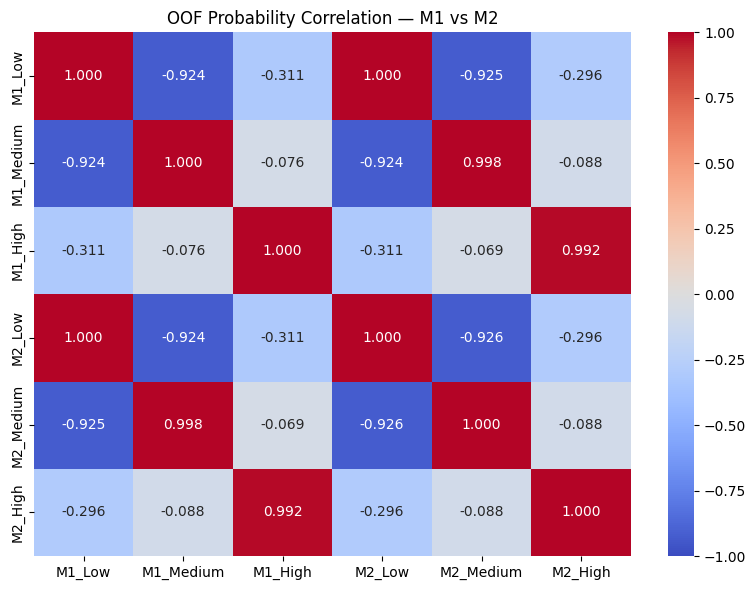


Cross-model correlations:
M1_Low    ↔ M2_Low   : 0.9998
M1_Medium ↔ M2_Medium: 0.9985
M1_High   ↔ M2_High  : 0.9920

Disagreement breakdown:
Model 2  High  Low  Medium
Model 1                   
High        0    0     421
Low         0    0       9
Medium    242   30       0


In [105]:
# Convert OOF probs to hard predictions first
oof_preds_m1 = oof_test_m1.argmax(axis=1)  # Model 1 class predictions
oof_preds_m2 = oof_test_m2.argmax(axis=1)  # Model 2 class predictions

# 1. Simple agreement rate
agreement = (oof_preds_m1 == oof_preds_m2).mean()
print(f'Agreement Rate: {agreement:.4f}')
print(f'Disagreement  : {1-agreement:.4f}')

# 2. Correlation between probability outputs
# Each model outputs 3 class probabilities
# Check correlation per class
prob_df = pd.DataFrame({
    'M1_Low'   : oof_test_m1[:, 0],
    'M1_Medium': oof_test_m1[:, 1],
    'M1_High'  : oof_test_m1[:, 2],
    'M2_Low'   : oof_test_m2[:, 0],
    'M2_Medium': oof_test_m2[:, 1],
    'M2_High'  : oof_test_m2[:, 2],
})

corr = prob_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', 
            cmap='coolwarm', center=0,
            vmin=-1, vmax=1)
plt.title('OOF Probability Correlation — M1 vs M2')
plt.tight_layout()
plt.show()

# 3. The key numbers to look at
print('\nCross-model correlations:')
print(f"M1_Low    ↔ M2_Low   : {prob_df['M1_Low'].corr(prob_df['M2_Low']):.4f}")
print(f"M1_Medium ↔ M2_Medium: {prob_df['M1_Medium'].corr(prob_df['M2_Medium']):.4f}")
print(f"M1_High   ↔ M2_High  : {prob_df['M1_High'].corr(prob_df['M2_High']):.4f}")

# 4. Where do they disagree — confusion between models
disagree_mask = oof_preds_m1 != oof_preds_m2
print(f'\nDisagreement breakdown:')
print(pd.crosstab(
    pd.Series(oof_preds_m1[disagree_mask]).map({0:'Low',1:'Medium',2:'High'}),
    pd.Series(oof_preds_m2[disagree_mask]).map({0:'Low',1:'Medium',2:'High'}),
    rownames=['Model 1'],
    colnames=['Model 2']
))

since the correlation scores are about 99% it doesnt make any sense to build an ensemble, we wont get any different results because both the models have ended up learning similar splits. Making the final predictions on the basis of the the heigher CV score which was by model 2.

In [107]:
preds = oof_test_m2.argmax(axis=1)
preds = pd.Series(preds).map({0: "Low", 1: "Medium", 2: "High"})

submission = pd.DataFrame({
    "id": test_df["id"],
    target: preds
})

submission.to_csv("submission_digit_decom_magic_score.csv", index=False)